In [1]:
from datasets import load_dataset

ds = load_dataset(
    "Marqo/polyvore",
    split="data[:500]"
)

len(ds)

500

In [5]:
from transformers import CLIPModel, CLIPProcessor
import torch

model_name = "patrickjohncyh/fashion-clip"

processor = CLIPProcessor.from_pretrained(model_name)
model = CLIPModel.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print("Loaded on:", device)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

d:\Projects\evidence_fashion_recommender\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ali29\.cache\huggingface\hub\models--patrickjohncyh--fashion-clip. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/4.46k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/568 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loaded on: cuda


Category: Day Dresses
Text: tibi knit long sleeve dress


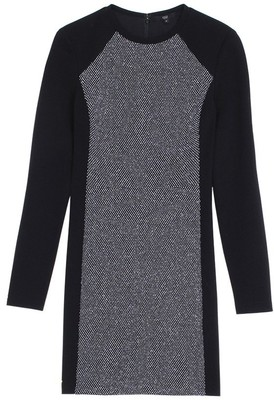

In [6]:
sample = ds[0]

print("Category:", sample["category"])
print("Text:", sample["text"])

image = sample["image"]

image

In [7]:
inputs = processor(
    images=image,
    return_tensors="pt"
)

inputs = {
    k: v.to(device)
    for k, v in inputs.items()
}

inputs.keys()

dict_keys(['pixel_values'])

In [10]:
with torch.no_grad():
    image_features = model.get_image_features(
        **inputs
    )

type(image_features)

transformers.modeling_outputs.BaseModelOutputWithPooling

In [12]:
with torch.no_grad():
    outputs = model.get_image_features(
        **inputs
    )

image_embedding = outputs.pooler_output

image_embedding.shape

torch.Size([1, 512])

In [13]:
embedding = (
    image_embedding
    .cpu()
    .numpy()
)

print("Shape:", embedding.shape)

embedding[0][:10]

Shape: (1, 512)


array([ 0.03846179, -0.4463264 ,  0.62003523, -0.08702356,  0.03044042,
       -0.92541975, -0.80099034,  0.05259752,  0.28967077,  0.5489907 ],
      dtype=float32)

FashionCLIP image representations are extracted from the pooled image embedding (`pooler_output`), producing a 512-dimensional feature vector for each fashion item.

In [14]:
import torch

def get_image_embedding(image):
    
    inputs = processor(
        images=image,
        return_tensors="pt"
    )
    
    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = model.get_image_features(
            **inputs
        )

    embedding = outputs.pooler_output

    embedding = embedding / embedding.norm(
        dim=-1,
        keepdim=True
    )

    return embedding.cpu()

In [18]:
df["outfit_id"] = (
    df["item_ID"]
    .str.split("_")
    .str[0]
)

outfit_id = "100002074"

outfit_items = df[
    df["outfit_id"] == outfit_id
]

outfit_items[
    ["item_ID", "category", "text"]
]

,item_ID,category,text
0,100002074_1,Day Dresses,tibi knit long sleeve dress
1,100002074_2,Boots,michael kors leather over-the-knee boots
2,100002074_3,Handbags,givenchy leather medium antigona duffel black
3,100002074_4,Sunglasses,bottega veneta acetate leather sunglasses
4,100002074_5,Floral Decor,pier imports stem
5,100002074_7,Coats,miranda coat


In [21]:
df["outfit_id"] = df["item_ID"].str.split("_").str[0]

query_idx = 0
query_item = df.iloc[query_idx]

same_outfit_id = query_item["outfit_id"]

same_outfit_boot_idx = df[
    (df["outfit_id"] == same_outfit_id) &
    (df["category"] == "Boots")
].index[0]

different_outfit_boot_idx = df[
    (df["outfit_id"] != same_outfit_id) &
    (df["category"] == "Boots")
].index[0]

print("Query item:")
print(query_item[["item_ID", "category", "text"]])

print("\nSame outfit boot:")
print(df.loc[same_outfit_boot_idx, ["item_ID", "category", "text"]])

print("\nDifferent outfit boot:")
print(df.loc[different_outfit_boot_idx, ["item_ID", "category", "text"]])

Query item:
item_ID                     100002074_1
category                    Day Dresses
text        tibi knit long sleeve dress
Name: 0, dtype: object

Same outfit boot:
item_ID                                  100002074_2
category                                       Boots
text        michael kors leather over-the-knee boots
Name: 1, dtype: str

Different outfit boot:
item_ID                  100333714_3
category                       Boots
text        soda grunge womens boots
Name: 183, dtype: str


In [22]:
query_emb = get_image_embedding(ds[query_idx]["image"])

same_boot_emb = get_image_embedding(ds[int(same_outfit_boot_idx)]["image"])

different_boot_emb = get_image_embedding(ds[int(different_outfit_boot_idx)]["image"])

same_score = torch.nn.functional.cosine_similarity(
    query_emb,
    same_boot_emb
)

different_score = torch.nn.functional.cosine_similarity(
    query_emb,
    different_boot_emb
)

print("Dress ↔ same outfit boot:", float(same_score))
print("Dress ↔ different outfit boot:", float(different_score))

Dress ↔ same outfit boot: 0.562386691570282
Dress ↔ different outfit boot: 0.3371083736419678


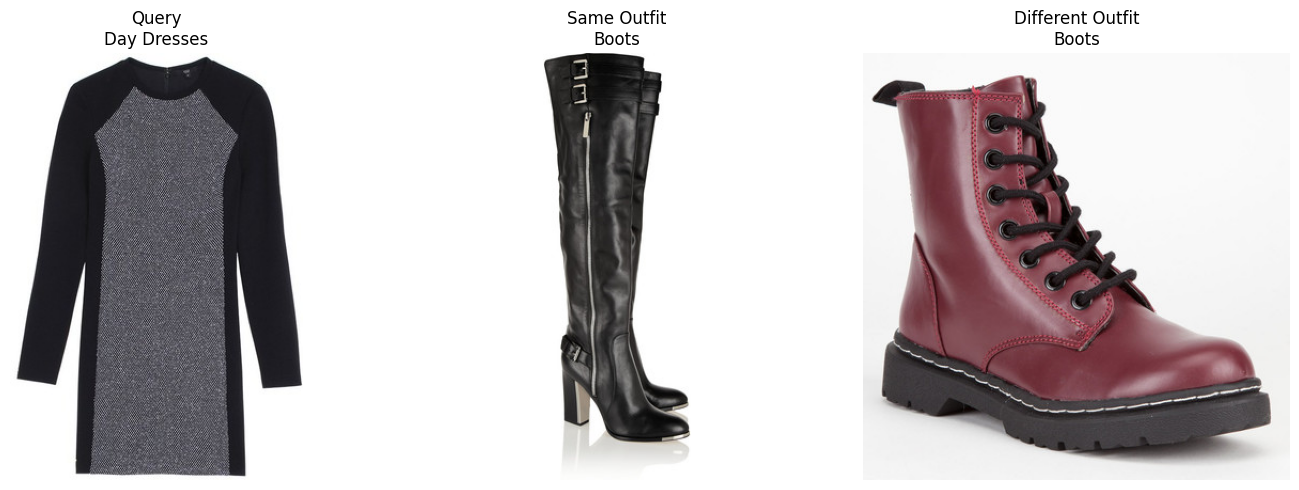

In [23]:
import matplotlib.pyplot as plt

query_img = ds[int(query_idx)]["image"]

same_boot_img = ds[int(same_outfit_boot_idx)]["image"]

different_boot_img = ds[int(different_outfit_boot_idx)]["image"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(query_img)
axes[0].set_title(
    f"Query\n{query_item['category']}"
)
axes[0].axis("off")

axes[1].imshow(same_boot_img)
axes[1].set_title(
    f"Same Outfit\n{df.loc[same_outfit_boot_idx, 'category']}"
)
axes[1].axis("off")

axes[2].imshow(different_boot_img)
axes[2].set_title(
    f"Different Outfit\n{df.loc[different_outfit_boot_idx, 'category']}"
)
axes[2].axis("off")

plt.tight_layout()
plt.show()